# Hockey Prediction

Author: Louis-Pierre Gagnaux  
Public Git Repo: https://github.com/gagnauxl/hockey_prediction  
Daten Swiss National League: https://www.sihf.ch/de/game-center/national-league/#/standing/rank/asc/page/0/

In [1]:
import data_service as dp
from team import Team
import ranking_regression as rr
import lin_regression as lr
import knn_regression as knn

In [2]:
X, y, df = dp.load()         # Lädt die Daten, bereitet sie vor und teilt sie in Features (X) und Zielvariable (y) auf   
print(f"Last 10 values of df: \n{df[['Home_Id', 'Away_Id', 'Home', 'Away', 'Resultat', 'OT/SO', 'Points']].head(10).to_string()}")
print(f"Features: {X.shape}")
#X.info()
print(X.head())
print(f"\nShape of target variable y: {y.shape}\n{y[:5]}")

Last 10 values of df: 
   Home_Id  Away_Id                       Home                Away Resultat OT/SO  Points
0        0       10            HC Ambri-Piotta          EHC Kloten      2:1   NaN       3
1        1       12                   HC Davos         Lausanne HC      4:1   NaN       3
2        2       11          Fribourg-Gottéron           HC Lugano      3:2    OT       2
3        3        8         Genève-Servette HC            HC Ajoie      5:3   NaN       3
4        4       13  SC Rapperswil-Jona Lakers          SCL Tigers      5:1   NaN       3
5        5        7                  ZSC Lions     EHC Biel-Bienne      4:3   NaN       3
6        6        9                     EV Zug             SC Bern      3:0   NaN       3
7        7        1            EHC Biel-Bienne            HC Davos      1:4   NaN       0
8        8        5                   HC Ajoie           ZSC Lions      0:4   NaN       0
9        9        3                    SC Bern  Genève-Servette HC      2:1  

## 1. Linear Regression

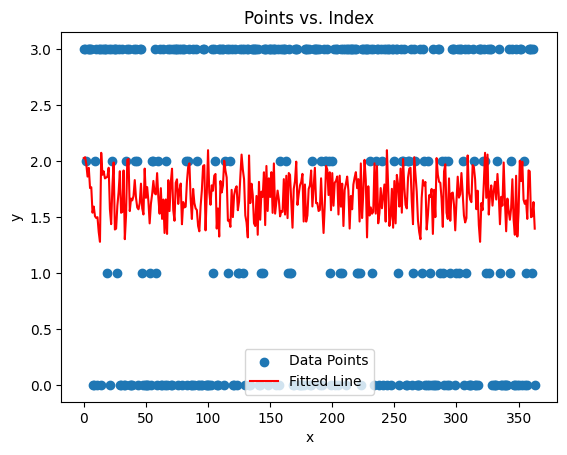

In [3]:
model=lr.fit(X, y) 
dp.plot_results(df, model)

Number of training items: 280, test items: 84
Training on rounds 0 to 40, testing on rounds 40 to 52


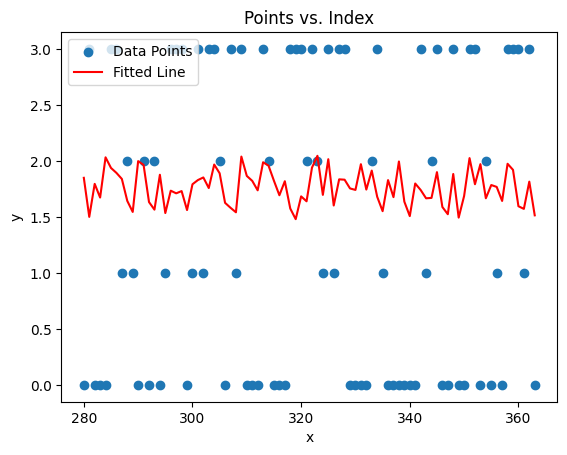

Predicted values y_hut) are rounded:
Model RMSE: 2.0557700445795186
Model R^2: -1.4581650317368715
Model Accuracy: 0.34523809523809523


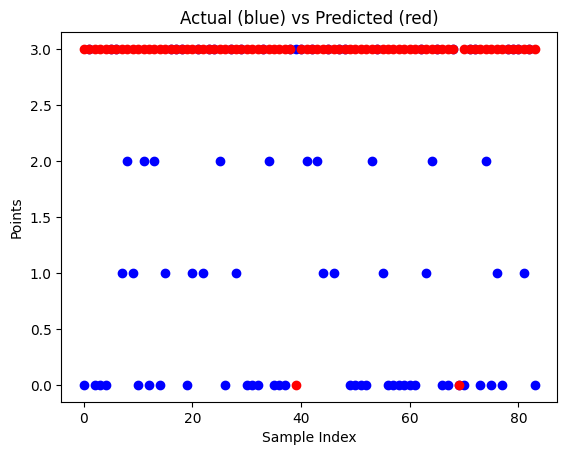

In [4]:
# train 40 Runden, test letzte 12 Runden
lr.analyze_model_performance(df=df, X=X, y=y, train_idx_start=0, train_idx_end=40, test_idx_start=40, test_idx_end=52)

Die vorausgesagten Punkte für sind letzten 12 Runden (84 Spiele) sind rot dargestellt und überschreiben die tatsächlichen Werte (blau). Je mehr man blaue Punkte sieht, desto schlechter ist das Modell. Die Accuracy von 0.35 ist entsprechend schlecht. Raten wäre vermutlich besser.

Aber: Die letzten Runden vor den Playoffs werden ganz anders gespielt und sind oft sehr unvorhersehbar sind, weil Teams, die schon qualifiziert sind, nicht mehr so motiviert sind, und Teams, die sich noch qualifizieren müssen, alles geben. Deshalb ist es vermutlich **falsch auf die ersten Runden zu trainieren und den letzten Runden zu testen.**

Number of training items: 70, test items: 70
Training on rounds 0 to 10, testing on rounds 10 to 20


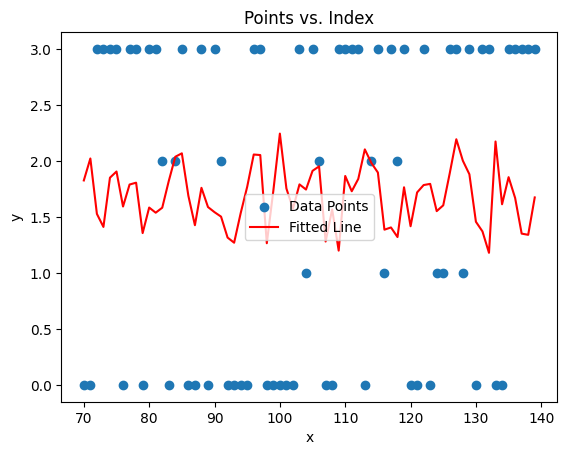

Predicted values y_hut) are rounded:
Model RMSE: 1.8935982376719422
Model R^2: -0.8763348996155484
Model Accuracy: 0.4857142857142857


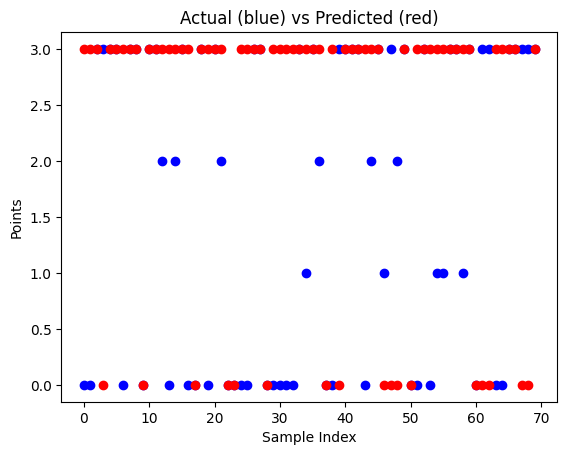

In [5]:
# train 10 Runden, test nächste 10 Runde
lr.analyze_model_performance(df=df, X=X, y=y, train_idx_start=0, train_idx_end=10, test_idx_start=10, test_idx_end=20) 

Was sich bestätigt, wenn auf die ersten 10 Runden trainiert und den nächsten 10 Runden testet, ist die Accuracy (0.49) besser.

# 2. Vorausage nach Ranking

Vorhersage der Punkte basierend auf der Rangliste der Teams, die aus den vorherigen Spielen erstellt wird. Diese Taktik sollte man schlagen können.

Number of training items: 70, test items: 70
Training on rounds 0 to 10, testing on rounds 10 to 20
                         Team  Punkte  Spiele
0                 Lausanne HC      27      11
1                    HC Davos      26      10
2           Fribourg-Gottéron      21      10
3          Genève-Servette HC      20      10
4   SC Rapperswil-Jona Lakers      20      10
5                   ZSC Lions      17      10
6                      EV Zug      17      10
7                  EHC Kloten      12      11
8                  SCL Tigers      11      10
9             EHC Biel-Bienne      11       9
10                  HC Lugano       8      10
11                    SC Bern       8       9
12            HC Ambri-Piotta       7      10
13                   HC Ajoie       5      10
Model RMSE: 1.886038933093073
Model R^2: -0.8613840239214008
Model Accuracy: 0.4714285714285714


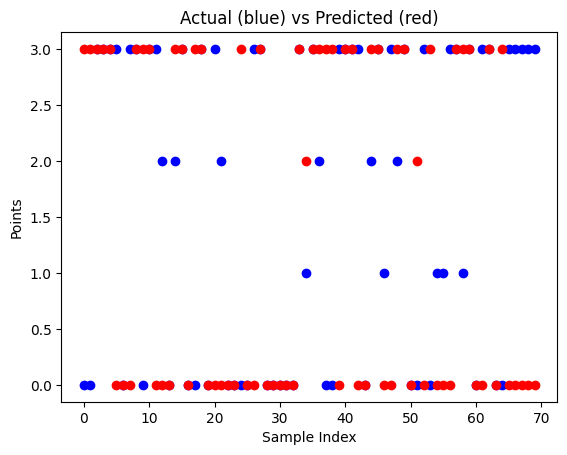

In [6]:
rr.analyze_model_performance(df=df, X=X, y=y, train_idx_start=0, train_idx_end=10, test_idx_start=10, test_idx_end=20)

Accuracy ist ca. 0.47, vergleichbar mit linearer Regression

# 3. KNN: k-Nearest-Neighbor-Algorithmus

Auch mit KNN, und dem Trainieren auf den ersten 10 Runden und dem Testen auf den auf den folgenden 10 Runden, erhalten wir eine ähnlich Accuracy.

Number of training items: 70, test items: 70
Training on rounds 0 to 10, testing on rounds 10 to 20
Model RMSE: 1.9309509130403675
Model R^2: -0.9510892780862874
Model Accuracy: 0.42857142857142855


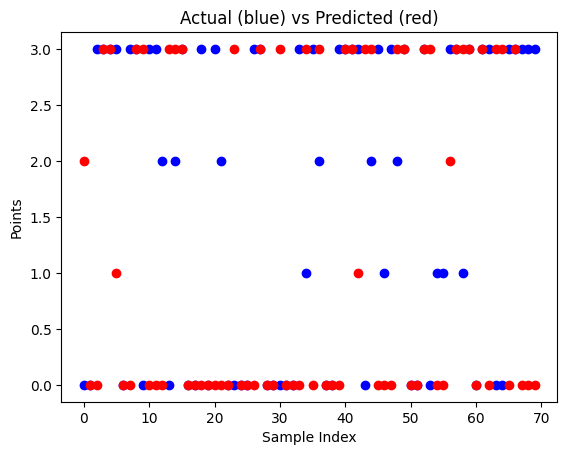

In [7]:
knn.analyze_model_performance(df=df, X=X, y=y, train_idx_start=0, train_idx_end=10, test_idx_start=10, test_idx_end=20)

## 3.1 Ein Beispiel für Overfitting

Trainiert man alle Spiele, erhält man ein viel bessere Accuracy. Deshalb ist so wichtig Train-Set und Test-Set unterschiedlich zu halten um eine richtige Crossvalidierung zu erhalten.

Number of training items: 364, test items: 70
Training on rounds 0 to 52, testing on rounds 42 to 52
Model RMSE: 1.3522468075656264
Model R^2: -0.03751736915238557
Model Accuracy: 0.6571428571428571


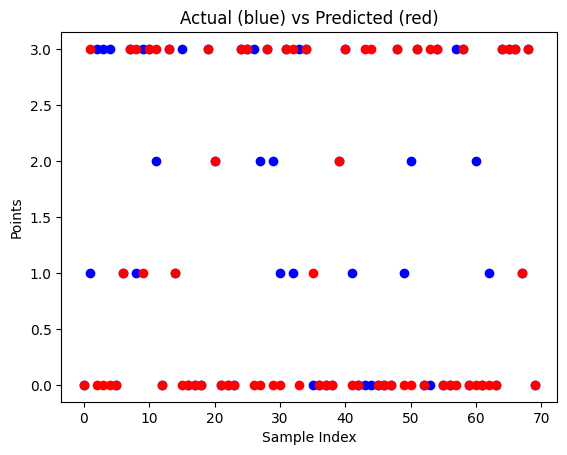

In [8]:
knn.analyze_model_performance(df=df, X=X, y=y, train_idx_start=0, train_idx_end=52, test_idx_start=42, test_idx_end=52)

# 4. ELO-Rating

ELO Rating kommt eigentlich vom Schach und dient dazu die Spielstärke eines Spielers zu bestimmen, ohne dass alle Spieler gegeneinander gespielt haben müssen. Das kann man auch für Teams anwenden, indem man z.B. die letzten 5 Spiele anschaut und die Rangliste der letzten 5 Spiele bestimmt. Mit Elo ist das aussagekräftiger als nur eine Rangliste von Punkten, weil das Gewinnen gegen einen schwachen weniger während gegen einen starken Gegner mehr ELO-Punkte gibt und so eine bessere Aussage liefert.